In [31]:
import os
import sys

import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


sys.path.append(os.path.join(os.path.abspath(""), "../src/python"))

from git_operate import get_repo
from config import RESULT_DIR, LANGUAGES

In [ ]:
def get_commits_num(language: str, name_with_owner: str):
    if language == "java":
        introduction_date = "2014-03-17"
    elif language == "javascript":
        introduction_date = "2014-06-01"
    elif language == "ruby":
        introduction_date = "2009-01-29"
    elif language == "php":
        introduction_date = "2019-11-27"
    elif language == "csharp":
        introduction_date = "2007-11-18"
    elif language == "cpp":
        introduction_date = "2010-8-12"
    else:
        raise ValueError(f"Unsupported language: {language}")

    repo = get_repo(name_with_owner, language)

    all_commits_num = repo.commit().count()

    for commit in repo.iter_commits(since=introduction_date):
        pass

    return all_commits_num - commit.count()


def get_language_df(language: str) -> pd.DataFrame:
    """RQ1のDataFrameを取得

    Args:
        language (str): ["java", "javascript", "ruby", "php", "csharp", "cpp"]

    Returns:
        pd.DataFrame: ['project', 'commit_num', 'replace_count', 'insert_count', 'update_count', 'delete_count', 'all_commits_num']
    """
    language_csv_path = RESULT_DIR / "rq1" / f"{language}.csv"

    if language_csv_path.exists():
        return pd.read_csv(language_csv_path)

    res = pd.DataFrame(
        columns=[
            "project",
            "commit_num",
            "replace_count",
            "insert_count",
            "update_count",
            "delete_count",
            "all_commits_num",
        ]
    )

    base_dir = RESULT_DIR / "lambda_replacement" / language
    project_paths = list(base_dir.glob("*/**/*.pkl"))

    for i, project_path in tqdm(enumerate(project_paths), total=len(project_paths)):
        df = pd.read_pickle(project_path)

        name_with_owner = f"{project_path.parent.name}/{project_path.stem}"

        replace_df = df[((df["status"] == "insert") | (df["status"] == "update"))]

        if replace_df.shape[0] == 0:
            continue

        commit_num = replace_df["commit"].unique().shape[0]
        insert_count = df[df["status"] == "insert"].shape[0]
        update_count = df[df["status"] == "update"].shape[0]
        delete_count = df[df["status"] == "delete"].shape[0]

        res.loc[i] = [
            name_with_owner,
            commit_num,
            insert_count + update_count,
            insert_count,
            update_count,
            delete_count,
            get_commits_num(language, name_with_owner),
        ]

    res.reset_index(drop=True, inplace=True)

    res.to_csv(language_csv_path, index=False)

    return res


def get_all_df():
    results_df = pd.DataFrame(
        columns=[
            "project_num",
            "commit_num",
            "replace_count",
            "delete_count",
            "insert_count",
            "update_count",
            "all_commits_num",
        ]
    )

    for language in LANGUAGES:
        df = get_language_df(language)

        results_df.loc[language] = [
            df.shape[0],
            df["commit_num"].sum(),
            df["replace_count"].sum(),
            df["delete_count"].sum(),
            df["insert_count"].sum(),
            df["update_count"].sum(),
            df["all_commits_num"].sum(),
        ]

    results_df.sort_values("project_num", inplace=True, ascending=True)

    results_df.to_csv(RESULT_DIR / "rq1" / "rq1.csv", index=True)

    return results_df

In [40]:
all_df = get_all_df()

all_df

,project_num,commit_num,replace_count,delete_count,insert_count,update_count,all_commits_num
php,18,76,726,152,726,0,18237
ruby,35,66,175,120,175,0,75881
cpp,80,1162,1970,3792,1970,0,469290
java,112,1115,4084,1768,4084,0,220012
javascript,160,1340,10938,5837,10938,0,101301
csharp,256,2601,5895,9575,5895,0,252818


### Replacemet Project

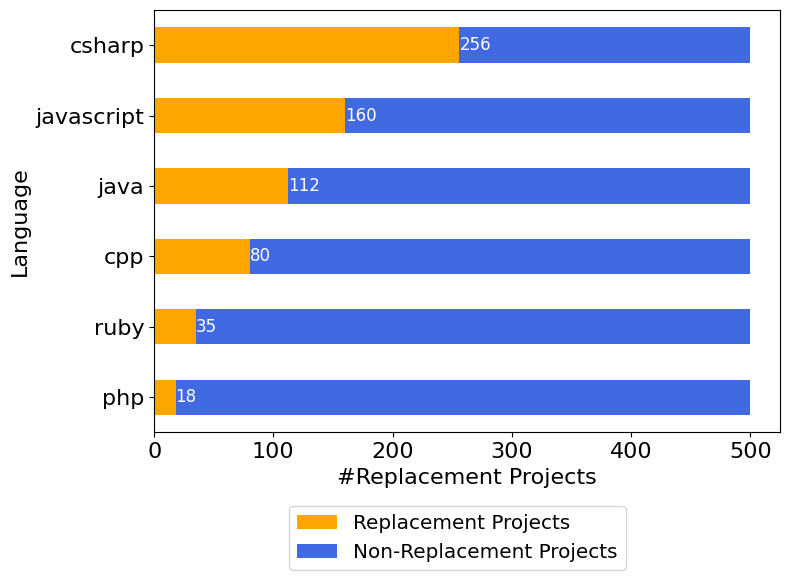

In [27]:
all_df["remain_project_num"] = 500 - all_df["project_num"]

ax = all_df[["project_num", "remain_project_num"]].plot.barh(
    stacked=True,
    color=["orange", "royalblue"],
    figsize=(8, 6),
    fontsize=16,
)

ax.bar_label(ax.containers[0], color="white", fontsize=12)

ax.legend(
    ["Replacement Projects", "Non-Replacement Projects"],
    loc="center left",  # グラフの外（左）に配置
    bbox_to_anchor=(0.2, -0.25),  # 凡例をグラフの右外側中央に配置
    fontsize="x-large",  # フォントサイズを変更
    frameon=True,  # フレームを表示
)

ax.set_xlabel("#Replacement Projects", fontsize=16)
ax.set_ylabel("Language", fontsize=16)

plt.tight_layout()  # レイアウトの調整

plt.savefig(RESULT_DIR / "rq1" / "replacement_project_num.pdf")  # 画像の保存
plt.show()
plt.close()

### Replacemet Project(ratio)

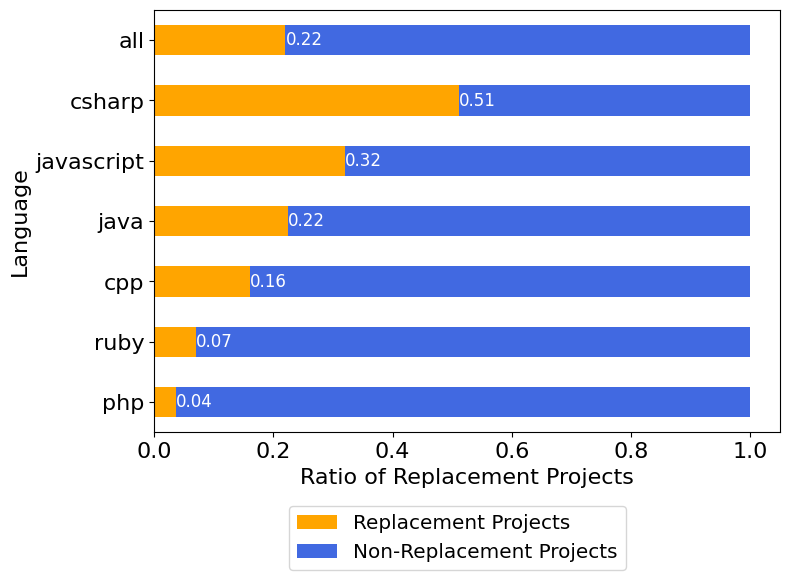

In [28]:
# 全体の行も追加
all_df.loc["all"] = all_df.sum()

all_df["project_frac"] = all_df["project_num"] / 500

all_df.loc["all", "project_frac"] = all_df.loc["all", "project_num"] / (500 * 6)

all_df["remain_project_frac"] = 1 - all_df["project_frac"]

ax = all_df[["project_frac", "remain_project_frac"]].plot.barh(
    stacked=True,
    color=["orange", "royalblue"],
    figsize=(8, 6),
    fontsize=16,
)

ax.bar_label(ax.containers[0], color="white", fontsize=12, fmt="%.2f")

ax.set_xlabel("Ratio of Replacement Projects", fontsize=16)
ax.set_ylabel("Language", fontsize=16)

ax.legend(
    ["Replacement Projects", "Non-Replacement Projects"],
    loc="center left",  # グラフの外（左）に配置
    bbox_to_anchor=(0.2, -0.25),  # 凡例をグラフの右外側中央に配置
    fontsize="x-large",  # フォントサイズを変更
    frameon=True,  # フレームを表示
)

plt.tight_layout()  # レイアウトの調整
plt.savefig(RESULT_DIR / "rq1" / "replacement_project_ratio.pdf")  # 画像の保存
plt.show()
plt.close()

### violin plot(Replacement Count)

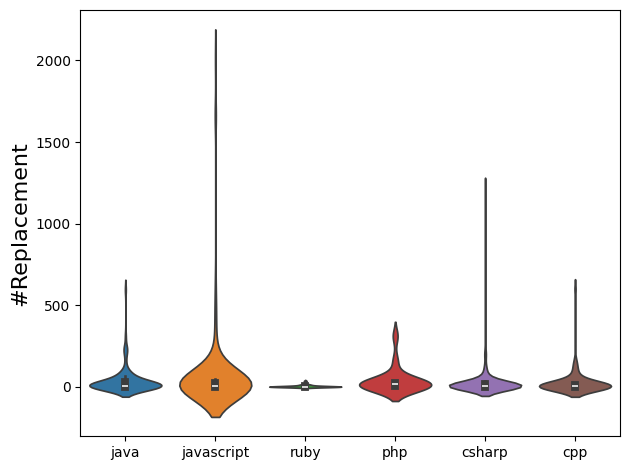

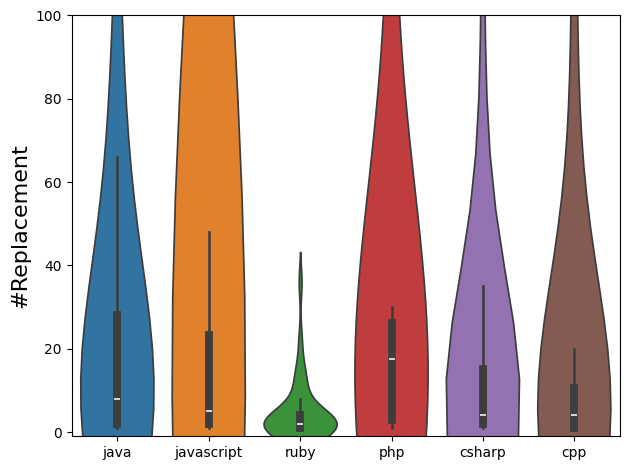

In [34]:
res = pd.DataFrame(
    columns=[
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
    ]
)

xs = []
ticks = []
for language in LANGUAGES:
    df = get_language_df(language)

    res.loc[language] = df["replace_count"].describe()

    xs.append(df["replace_count"].values)
    ticks.append(language)

    # sns.violinplot(df["replace_count"])

    # plt.xlabel(language, fontsize=16)
    # plt.ylabel("#Replacement", fontsize=16)
    # plt.tight_layout()  # レイアウトの調整
    # plt.savefig(RESULT_DIR / "rq1" / f"replacement_count_{language}.pdf")  # 画像の保存
    # plt.show()
    # plt.close()


ax = sns.violinplot(xs)
ax.set_xticks(range(len(ticks)), labels=ticks)
# plt.xlabel("Language", fontsize=16)
plt.ylabel("#Replacement", fontsize=16)
# plt.title("Replacement Commit Frequency", fontsize=16)
plt.tight_layout()  # レイアウトの調整
plt.savefig(RESULT_DIR / "rq1" / "replacement_num_violinplot.pdf")  # 画像の保存
plt.show()
plt.close()

ax = sns.violinplot(xs)
ax.set_ybound(-1, 100)
ax.set_xticks(range(len(ticks)), labels=ticks)
# plt.xlabel("Language", fontsize=16)
plt.ylabel("#Replacement", fontsize=16)
# plt.title("Replacement Commit Frequency", fontsize=16)
plt.tight_layout()  # レイアウトの調整
plt.savefig(RESULT_DIR / "rq1" / "replacement_num_violinplot_scope.pdf")  # 画像の保存
plt.show()
plt.close()

### violin plot(commit frequency)

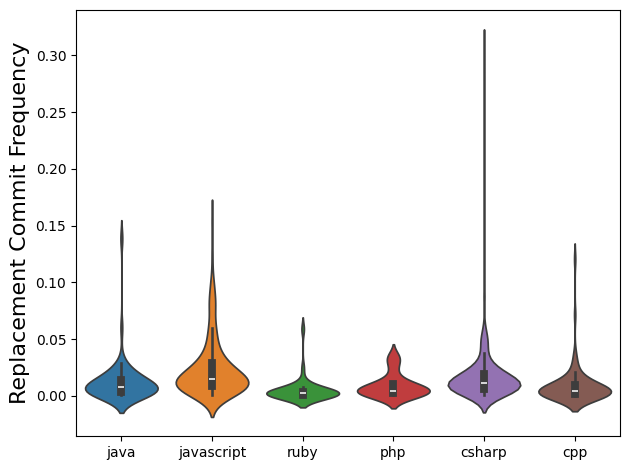

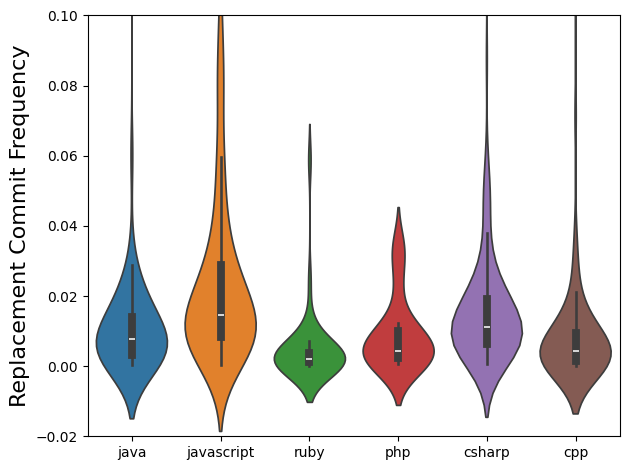

In [35]:
res = pd.DataFrame(
    columns=[
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
    ]
)

xs = []
xs_remove_outliers = []
ticks = []
for language in LANGUAGES:
    df = get_language_df(language)

    df["replacement_commit_frequency"] = df["commit_num"] / df["all_commits_num"]

    res.loc[language] = df["replacement_commit_frequency"].describe()

    xs.append(df["replacement_commit_frequency"].values)
    ticks.append(language)

    # sns.violinplot(df["replacement_commit_frequency"])

    # plt.xlabel(language, fontsize=16)
    # plt.ylabel("Replacement Commit Frequency", fontsize=16)
    # plt.tight_layout()  # レイアウトの調整
    # plt.savefig(
    #     RESULT_DIR / "rq1" / f"replacement_commit_frequency_{language}.pdf"
    # )  # 画像の保存
    # plt.show()
    # plt.close()

ax = sns.violinplot(xs)
ax.set_xticks(range(len(ticks)), labels=ticks)
# plt.xlabel("Language", fontsize=16)
plt.ylabel("Replacement Commit Frequency", fontsize=16)
# plt.title("Replacement Commit Frequency", fontsize=16)
plt.tight_layout()  # レイアウトの調整
plt.savefig(
    RESULT_DIR / "rq1" / "replacement_commit_frequency_violinplot.pdf"
)  # 画像の保存
plt.show()
plt.close()

ax = sns.violinplot(xs)
ax.set_xticks(range(len(ticks)), labels=ticks)
ax.set_ybound(-0.02, 0.1)
# plt.xlabel("Language", fontsize=16)
plt.ylabel("Replacement Commit Frequency", fontsize=16)
# plt.title("Replacement Commit Frequency", fontsize=16)
plt.tight_layout()  # レイアウトの調整
plt.savefig(
    RESULT_DIR / "rq1" / "replacement_commit_frequency_violinplot_scope.pdf"
)  # 画像の保存
plt.show()
plt.close()

### violin plot(replacements_per_commits)

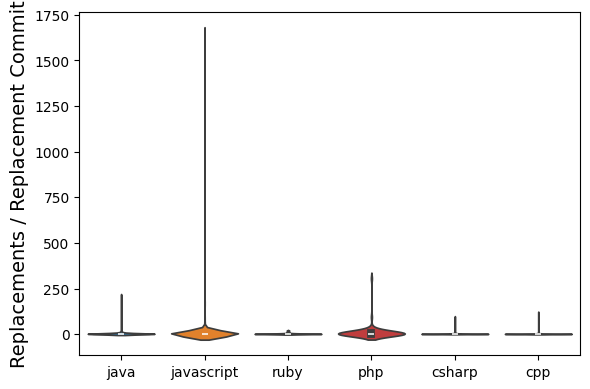

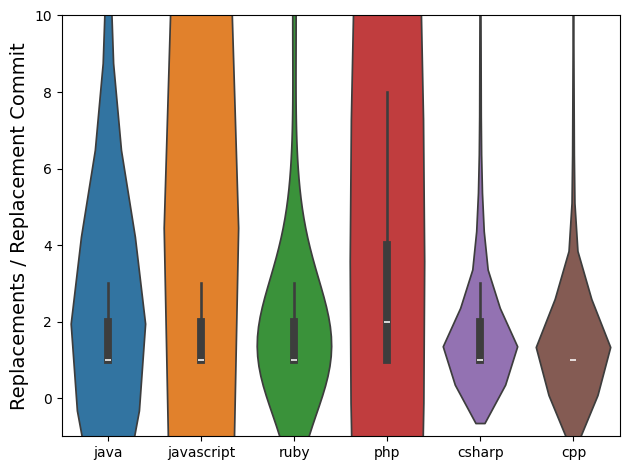

In [36]:
res = pd.DataFrame(
    columns=[
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
    ]
)

xs = []
all_x_ticks = []
for language in LANGUAGES:
    lang_res = pd.DataFrame(
        columns=[
            "project",
            "commit",
            "replace_count",
        ]
    )

    base_dir = RESULT_DIR / "lambda_replacement" / language
    project_paths = list(base_dir.glob("*/**/*.pkl"))

    for project_path in project_paths:
        df = pd.read_pickle(project_path)

        replace_df = df[((df["status"] == "insert") | (df["status"] == "update"))]

        commit_nums = (
            replace_df.groupby("commit").size().reset_index(name="replace_count")
        )
        commit_nums["project"] = f"{project_path.parent.name}/{project_path.stem}"

        lang_res = pd.concat([lang_res, commit_nums], ignore_index=True)

    lang_res["replace_count"] = lang_res["replace_count"].astype(int)
    xs.append(lang_res["replace_count"].values)
    all_x_ticks.append(language)

    # plt.figure(figsize=(6, 4))
    # ax = sns.violinplot(y=lang_res["replace_count"].values)

    # plt.xlabel(language, fontsize=16)
    # plt.ylabel("Replacements per Commit", fontsize=16)
    # # plt.title("Replacements per Commit", fontsize=16)
    # plt.tight_layout()  # レイアウトの調整
    # plt.savefig(
    #     RESULT_DIR / "rq1" / f"rq1_replacements_per_commit_{language}.pdf"
    # )  # 画像の保存
    # plt.show()
    # plt.close()

    res.loc[language] = lang_res["replace_count"].describe()

plt.figure(figsize=(6, 4))

ax = sns.violinplot(data=xs)
ax.set_xticks(range(len(all_x_ticks)), labels=all_x_ticks)
# plt.xlabel("Language", fontsize=16)
plt.ylabel("Replacements / Replacement Commit", fontsize=14)
# plt.title("Replacement Commit Frequency", fontsize=16)
plt.tight_layout()  # レイアウトの調整
plt.savefig(
    RESULT_DIR / "rq1" / "rq1_replacements_per_replacement_commit_violinplot.pdf"
)  # 画像の保存
plt.show()
plt.close()

ax = sns.violinplot(data=xs)
ax.set_xticks(range(len(all_x_ticks)), labels=all_x_ticks)
ax.set_ybound(-1, 10)
# plt.xlabel("Language", fontsize=16)
plt.ylabel("Replacements / Replacement Commit", fontsize=14)
# plt.title("Replacement Commit Frequency", fontsize=16)
plt.tight_layout()  # レイアウトの調整
plt.savefig(
    RESULT_DIR / "rq1" / "rq1_replacements_per_replacement_commit_violinplot_scope.pdf"
)  # 画像の保存
plt.show()